# Mental Health Disorder Prediction by Symptoms

### Problem Statement

###### 
  Mental health disorders like depression are underdiagnosed, delaying treatment and worsening outcomes. Build a model
 to predict disorder risk based on self-reported symptoms, facilitating early screening. Focus on sensitivity for at-risk individuals, ensure fairness across demographics (e.g., age, gender, employment status), offer explainable symptom impacts for therapy
 guidance, and monitor drift (e.g., seasonal affective changes). Assume API deployment for telehealth apps or wellness platforms.

#### Referances

######
 Dataset Referance -  "Depression, Anxiety, Stress Scales Responses" dataset from Kaggle. It contains 42 features (DASS-42) questionnaire items on depression/anxiety/stress symptoms, demographics.

 Official Document for DASS-42 questioonare and Score Link 1 : https://upcommons.upc.edu/server/api/core/bitstreamsc357c588-e151-41c0-991e-45dd2f3303a5/content#:~:text=Depression:%203%2C%205%2C%2010,S%20columns%20(Table%201).

 Link 2 - https://www.scribd.com/document/523872913DASS-42-Scoring#:~:text=The%20DASS%2D42%20uses%20a%204%2Dpoint%20scale%20ranging,and%20extremely%20severe%20levels%20for%20each%20state.

 DASS-42 item mapping (1-indexed question numbers) 

### Data Preprocessing 

#### Step 1 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# !pip install shap
import shap
from fairlearn.metrics import MetricFrame
import joblib

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
# Ensemble Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Step 2 — Load & Clean Data

In [3]:
# Loading data
df = pd.read_csv("data.csv", delimiter='\t')

In [4]:
df.head()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,Q4I,Q4E,Q5A,Q5I,Q5E,Q6A,Q6I,Q6E,Q7A,Q7I,Q7E,Q8A,Q8I,Q8E,Q9A,Q9I,Q9E,Q10A,Q10I,Q10E,Q11A,Q11I,Q11E,Q12A,Q12I,Q12E,Q13A,Q13I,Q13E,Q14A,Q14I,Q14E,Q15A,Q15I,Q15E,Q16A,Q16I,Q16E,Q17A,Q17I,Q17E,Q18A,Q18I,Q18E,Q19A,Q19I,Q19E,Q20A,Q20I,Q20E,Q21A,Q21I,Q21E,Q22A,Q22I,Q22E,Q23A,Q23I,Q23E,Q24A,Q24I,Q24E,Q25A,Q25I,Q25E,Q26A,Q26I,Q26E,Q27A,Q27I,Q27E,Q28A,Q28I,Q28E,Q29A,Q29I,Q29E,Q30A,Q30I,Q30E,Q31A,Q31I,Q31E,Q32A,Q32I,Q32E,Q33A,Q33I,Q33E,Q34A,Q34I,Q34E,Q35A,Q35I,Q35E,Q36A,Q36I,Q36E,Q37A,Q37I,Q37E,Q38A,Q38I,Q38E,Q39A,Q39I,Q39E,Q40A,Q40I,Q40E,Q41A,Q41I,Q41E,Q42A,Q42I,Q42E,country,source,introelapse,testelapse,surveyelapse,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10,VCL1,VCL2,VCL3,VCL4,VCL5,VCL6,VCL7,VCL8,VCL9,VCL10,VCL11,VCL12,VCL13,VCL14,VCL15,VCL16,education,urban,gender,engnat,age,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,major
0,4,28,3890,4,25,2122,2,16,1944,4,8,2044,4,34,2153,4,33,2416,4,10,2818,4,13,2259,2,21,5541,1,38,4441,4,31,2451,4,24,3325,4,14,1416,4,37,5021,4,27,2342,4,39,2480,3,6,2476,4,35,1627,3,17,9050,3,30,7001,1,11,4719,4,20,2984,4,36,1313,4,42,2444,4,1,9880,4,2,4695,4,5,1677,3,4,6723,4,3,5953,2,26,8062,4,12,5560,4,7,3032,2,29,3316,3,40,3563,4,23,5594,4,41,1477,1,18,3885,2,9,5265,4,19,1892,3,22,4228,4,32,1574,4,15,2969,IN,2,19,167,166,1,5,7,7,7,7,7,5,1,1,1,0,0,1,1,0,1,0,0,1,0,0,0,1,1,1,2,3,2,2,16,1,1,1,12,1,10,2,1,2,NaN
1,4,2,8118,1,36,2890,2,35,4777,3,28,3090,4,10,5078,4,40,2790,3,18,3408,4,1,8342,3,37,916,2,32,1537,2,21,3926,2,25,3691,4,26,2004,4,4,8888,3,27,4109,3,19,4058,4,12,3692,2,6,3373,1,23,6015,1,16,3023,2,22,2670,3,3,5727,1,39,3641,2,33,2670,2,7,7649,3,11,2537,3,5,2907,4,9,1685,3,41,4726,3,17,6063,2,20,3307,3,14,4995,3,38,2505,2,34,2540,2,31,4359,3,15,3925,4,13,4609,2,30,3755,2,42,2323,1,24,5713,2,8,1334,2,29,5562,US,2,1,193,186,6,5,4,7,5,4,7,7,1,5,1,1,0,1,1,0,0,0,0,1,0,0,0,1,1,1,2,3,2,1,16,2,1,2,7,0,70,2,1,4,NaN
2,3,7,5784,1,33,4373,4,41,3242,1,13,6470,4,11,3927,3,9,3704,1,17,4550,3,5,3021,2,32,5864,4,21,3722,2,10,3424,1,36,3236,4,23,2489,1,34,7290,4,12,6587,4,22,3627,4,38,2905,2,18,2998,2,8,10233,1,16,4258,4,28,2888,3,4,59592,2,3,11732,4,2,8834,2,29,7358,1,30,4928,2,15,3036,1,19,4127,2,37,3934,2,26,10782,4,1,8273,3,39,3501,1,27,3824,4,25,2141,3,6,17461,4,24,1557,4,40,4446,4,42,1883,2,35,5790,2,14,4432,1,20,2203,4,31,5768,PL,2,5,271,122,2,5,2,2,5,6,5,5,3,2,1,0,0,1,1,0,0,0,0,0,1,0,0,1,1,1,2,3,2,2,17,2,1,1,4,3,60,1,1,3,NaN
3,2,23,5081,3,11,6837,2,37,5521,1,27,4556,3,28,3269,3,26,3231,4,2,7138,2,19,3079,3,31,9650,3,17,4179,2,5,5928,1,21,2838,1,20,2560,4,29,5139,2,22,3597,2,35,3336,3,10,4506,1,14,2695,1,25,8128,2,15,3125,1,6,4061,1,40,4272,1,12,4029,1,9,5630,1,18,30631,2,24,9870,4,4,2411,1,16,9478,3,1,7618,3,32,12639,3,34,5378,1,41,8923,2,38,2977,4,3,5620,1,7,16760,1,8,6427,2,39,3760,1,13,4112,3,42,2769,4,33,4432,4,30,3643,2,36,3698,US,2,3,261,336,1,1,7,4,6,4,6,1,6,1,1,0,0,1,1,0,0,0,0,1,0,0,0,1,1,1,1,3,2,1,13,2,1,2,4,5,70,2,1,5,biology
4,2,36,3215,2,13,7731,3,5,4156,4,10,2802,4,2,5628,2,9,6522,4,34,2374,4,11,3054,4,7,2975,3,14,3524,2,33,3033,4,23,2132,4,17,1314,4,16,3181,4,26,2249,3,19,2623,4,35,3093,4,38,7098,4,37,1938,4,15,3502,3,32,4776,3,18,4463,4,4,2436,2,40,4047,4,31,3787,4,42,2102,2,1,12351,4,3,2410,2,22,5056,4,39,3343,3,27,3012,4,20,3520,4,8,1868,4,25,2536,3,24,3725,4,30,2130,3,29,3952,3,21,10694,3,41,3231,4,12,3604,4,28,1950,3,6,6265,MY,2,1766,164,157,2,5,3,6,5,5,5,6,3,3,1,1,0,1,1,0,0,1,0,1,0,0,1,1,1,1,3,2,2,2,19,2,2,3,10,1,10,2,1,4,Psychology


In [5]:
df.shape

(39775, 172)

In [6]:
df.info()
print(list(df.columns))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39775 entries, 0 to 39774
Columns: 172 entries, Q1A to major
dtypes: int64(170), object(2)
memory usage: 52.2+ MB
['Q1A', 'Q1I', 'Q1E', 'Q2A', 'Q2I', 'Q2E', 'Q3A', 'Q3I', 'Q3E', 'Q4A', 'Q4I', 'Q4E', 'Q5A', 'Q5I', 'Q5E', 'Q6A', 'Q6I', 'Q6E', 'Q7A', 'Q7I', 'Q7E', 'Q8A', 'Q8I', 'Q8E', 'Q9A', 'Q9I', 'Q9E', 'Q10A', 'Q10I', 'Q10E', 'Q11A', 'Q11I', 'Q11E', 'Q12A', 'Q12I', 'Q12E', 'Q13A', 'Q13I', 'Q13E', 'Q14A', 'Q14I', 'Q14E', 'Q15A', 'Q15I', 'Q15E', 'Q16A', 'Q16I', 'Q16E', 'Q17A', 'Q17I', 'Q17E', 'Q18A', 'Q18I', 'Q18E', 'Q19A', 'Q19I', 'Q19E', 'Q20A', 'Q20I', 'Q20E', 'Q21A', 'Q21I', 'Q21E', 'Q22A', 'Q22I', 'Q22E', 'Q23A', 'Q23I', 'Q23E', 'Q24A', 'Q24I', 'Q24E', 'Q25A', 'Q25I', 'Q25E', 'Q26A', 'Q26I', 'Q26E', 'Q27A', 'Q27I', 'Q27E', 'Q28A', 'Q28I', 'Q28E', 'Q29A', 'Q29I', 'Q29E', 'Q30A', 'Q30I', 'Q30E', 'Q31A', 'Q31I', 'Q31E', 'Q32A', 'Q32I', 'Q32E', 'Q33A', 'Q33I', 'Q33E', 'Q34A', 'Q34I', 'Q34E', 'Q35A', 'Q35I', 'Q35E', 'Q36A', 'Q36I', 'Q36E'

In [7]:
# Missing Values check
df.isnull().sum()

Q1A                          0
Q1I                          0
Q1E                          0
Q2A                          0
Q2I                          0
Q2E                          0
Q3A                          0
Q3I                          0
Q3E                          0
Q4A                          0
Q4I                          0
Q4E                          0
Q5A                          0
Q5I                          0
Q5E                          0
Q6A                          0
Q6I                          0
Q6E                          0
Q7A                          0
Q7I                          0
Q7E                          0
Q8A                          0
Q8I                          0
Q8E                          0
Q9A                          0
Q9I                          0
Q9E                          0
Q10A                         0
Q10I                         0
Q10E                         0
Q11A                         0
Q11I                         0
Q11E    

* Major having Missing values = 11425
* Country having Missing values = 2

In [8]:
df.describe()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,Q4I,Q4E,Q5A,Q5I,Q5E,Q6A,Q6I,Q6E,Q7A,Q7I,Q7E,Q8A,Q8I,Q8E,Q9A,Q9I,Q9E,Q10A,Q10I,Q10E,Q11A,Q11I,Q11E,Q12A,Q12I,Q12E,Q13A,Q13I,Q13E,Q14A,Q14I,Q14E,Q15A,Q15I,Q15E,Q16A,Q16I,Q16E,Q17A,Q17I,Q17E,Q18A,Q18I,Q18E,Q19A,Q19I,Q19E,Q20A,Q20I,Q20E,Q21A,Q21I,Q21E,Q22A,Q22I,Q22E,Q23A,Q23I,Q23E,Q24A,Q24I,Q24E,Q25A,Q25I,Q25E,Q26A,Q26I,Q26E,Q27A,Q27I,Q27E,Q28A,Q28I,Q28E,Q29A,Q29I,Q29E,Q30A,Q30I,Q30E,Q31A,Q31I,Q31E,Q32A,Q32I,Q32E,Q33A,Q33I,Q33E,Q34A,Q34I,Q34E,Q35A,Q35I,Q35E,Q36A,Q36I,Q36E,Q37A,Q37I,Q37E,Q38A,Q38I,Q38E,Q39A,Q39I,Q39E,Q40A,Q40I,Q40E,Q41A,Q41I,Q41E,Q42A,Q42I,Q42E,source,introelapse,testelapse,surveyelapse,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10,VCL1,VCL2,VCL3,VCL4,VCL5,VCL6,VCL7,VCL8,VCL9,VCL10,VCL11,VCL12,VCL13,VCL14,VCL15,VCL16,education,urban,gender,engnat,age,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize
count,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.00000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,3.977500e+04,3.977500e+04,3.977500e+04,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.00000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000
mean,2.619485,21.555977,6.970591e+03,2.172269,21.248070,5.332376e+03,2.226097,21.583004,7.426446e+03,1.950170,21.499837,7.128728e+03,2.521458,21.492118,5.919306e+03,2.540214,21.562866,5.724097e+03,1.924928,21.528422,9.776971e+03,2.480427,21.569227,4.444627e+03,2.669591,21.582778,1.833083e+04,2.447316,21.417574,9.157494e+03,2.803294,21.434041,5.490152e+03,2.425669,21.485808,6.570469e+03,2.784538,21.501446,3.931872e+03,2.580264,21.571791,1.034875e+04,1.826901,21.501672,5.243594e+03,2.519573,21.459485,6.446743e+03,2.658605,21.497021,5.197918e+03,2.477536,21.530685,7.293520e+03,1.946298,21.549994,1.124446e+04,2.323042,21.519899,4.965477e+03,2.349591,21.566989,5.596290e+03,2.344488,21.516229,6.865094e+03,1.562288,21.479246,4.603325e+03,2.437109,21.531263,8.142970e+03,2.184312,21.563193,1.408290e+04,2.658580,21.445179,5.336940e+03,2.612344,21.527366,8.448039e+03

In [9]:
# Segment columns
answer_cols  = [f'Q{i}A' for i in range(1, 43)]     # 42 DASS answers
latency_cols = [f'Q{i}E' for i in range(1, 43)]     # 42 elapsed times
order_cols   = [f'Q{i}I' for i in range(1, 43)]     # 42 item orders
tipi_cols = [f'TIPI{i}' for i in range(1, 11)]
vcl_cols = [f'VCL{i}' for i in range(1, 17)]
demographics = ['education', 'urban', 'gender', 'engnat', 'age', 'screensize', 'religion', 'orientation', 'race', 'married', 'familysize']

print(f'Answer_cols :  {len(answer_cols)}')
print(f'latency_cols : {len(latency_cols)}')
print(f'order_cols : {len(order_cols)}')

Answer_cols :  42
latency_cols : 42
order_cols : 42


In [10]:
print(answer_cols)
print(latency_cols)
print(order_cols)
print(tipi_cols)
print(vcl_cols)
print(demographics)

['Q1A', 'Q2A', 'Q3A', 'Q4A', 'Q5A', 'Q6A', 'Q7A', 'Q8A', 'Q9A', 'Q10A', 'Q11A', 'Q12A', 'Q13A', 'Q14A', 'Q15A', 'Q16A', 'Q17A', 'Q18A', 'Q19A', 'Q20A', 'Q21A', 'Q22A', 'Q23A', 'Q24A', 'Q25A', 'Q26A', 'Q27A', 'Q28A', 'Q29A', 'Q30A', 'Q31A', 'Q32A', 'Q33A', 'Q34A', 'Q35A', 'Q36A', 'Q37A', 'Q38A', 'Q39A', 'Q40A', 'Q41A', 'Q42A']
['Q1E', 'Q2E', 'Q3E', 'Q4E', 'Q5E', 'Q6E', 'Q7E', 'Q8E', 'Q9E', 'Q10E', 'Q11E', 'Q12E', 'Q13E', 'Q14E', 'Q15E', 'Q16E', 'Q17E', 'Q18E', 'Q19E', 'Q20E', 'Q21E', 'Q22E', 'Q23E', 'Q24E', 'Q25E', 'Q26E', 'Q27E', 'Q28E', 'Q29E', 'Q30E', 'Q31E', 'Q32E', 'Q33E', 'Q34E', 'Q35E', 'Q36E', 'Q37E', 'Q38E', 'Q39E', 'Q40E', 'Q41E', 'Q42E']
['Q1I', 'Q2I', 'Q3I', 'Q4I', 'Q5I', 'Q6I', 'Q7I', 'Q8I', 'Q9I', 'Q10I', 'Q11I', 'Q12I', 'Q13I', 'Q14I', 'Q15I', 'Q16I', 'Q17I', 'Q18I', 'Q19I', 'Q20I', 'Q21I', 'Q22I', 'Q23I', 'Q24I', 'Q25I', 'Q26I', 'Q27I', 'Q28I', 'Q29I', 'Q30I', 'Q31I', 'Q32I', 'Q33I', 'Q34I', 'Q35I', 'Q36I', 'Q37I', 'Q38I', 'Q39I', 'Q40I', 'Q41I', 'Q42I']
['TIPI1', 'TIPI2

In [11]:
# Changing the questions values from range 1-4 to 0-3 as per DASS-42 (manual) - https://upcommons.upc.edu/server/api/core/bitstreams/c357c588-e151-41c0-991e-45dd2f3303a5/content#:~:text=Depression:%203%2C%205%2C%2010,S%20columns%20(Table%201).
df_1 = df.copy()
df_1[answer_cols] = df_1[answer_cols] - 1 
df_1[latency_cols] = df_1[latency_cols] - 1 
df_1[order_cols] = df_1[order_cols] - 1 

In [12]:
df_1 = df_1.drop_duplicates()
print(len(df))
print(len(df_1))

39775
39775


In [13]:
# Age Feature
df_1['age'].value_counts()

# Keep only rows with valid age (1–100). removed the outliers
df_1 = df_1[(df['age'] >= 10) & (df_1['age'] <= 80)]
print(len(df))
print(len(df_1))

39775
39764


#### Map DASS-42 questions to each condition

In [14]:
# Official DASS-42 questioonare/Score referance  Link 1: https://upcommons.upc.edu/server/api/core/bitstreams/c357c588-e151-41c0-991e-45dd2f3303a5/content#:~:text=Depression:%203%2C%205%2C%2010,S%20columns%20(Table%201).
# Link 2 - https://www.scribd.com/document/523872913/DASS-42-Scoring#:~:text=The%20DASS%2D42%20uses%20a%204%2Dpoint%20scale%20ranging,and%20extremely%20severe%20levels%20for%20each%20state.
# DASS-42 item mapping (1-indexed question numbers) 
DEPRESSION = [3, 5, 10, 13, 16, 17, 21, 24, 26, 31, 34, 37, 38, 42]
ANXIETY = [2, 4,  7,  9, 15, 19, 20, 23, 25, 28, 30, 36, 40, 41]
STRESS = [1, 6,  8, 11, 12, 14, 18, 22, 27, 29, 32, 33, 35, 39]

depression_cols = [f'Q{i}A' for i in DEPRESSION]
anxiety_cols = [f'Q{i}A' for i in ANXIETY]
stress_cols = [f'Q{i}A' for i in STRESS]

#### Compute scores & classify severity

In [15]:
# Total count as score -  Obtain the total score
df_1['depression_score']    = df_1[depression_cols].sum(axis=1)
df_1['anxiety_score'] = df_1[anxiety_cols].sum(axis=1)
df_1['stress_score'] = df_1[stress_cols].sum(axis=1)

In [16]:
df_1.head()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,Q4I,Q4E,Q5A,Q5I,Q5E,Q6A,Q6I,Q6E,Q7A,Q7I,Q7E,Q8A,Q8I,Q8E,Q9A,Q9I,Q9E,Q10A,Q10I,Q10E,Q11A,Q11I,Q11E,Q12A,Q12I,Q12E,Q13A,Q13I,Q13E,Q14A,Q14I,Q14E,Q15A,Q15I,Q15E,Q16A,Q16I,Q16E,Q17A,Q17I,Q17E,Q18A,Q18I,Q18E,Q19A,Q19I,Q19E,Q20A,Q20I,Q20E,Q21A,Q21I,Q21E,Q22A,Q22I,Q22E,Q23A,Q23I,Q23E,Q24A,Q24I,Q24E,Q25A,Q25I,Q25E,Q26A,Q26I,Q26E,Q27A,Q27I,Q27E,Q28A,Q28I,Q28E,Q29A,Q29I,Q29E,Q30A,Q30I,Q30E,Q31A,Q31I,Q31E,Q32A,Q32I,Q32E,Q33A,Q33I,Q33E,Q34A,Q34I,Q34E,Q35A,Q35I,Q35E,Q36A,Q36I,Q36E,Q37A,Q37I,Q37E,Q38A,Q38I,Q38E,Q39A,Q39I,Q39E,Q40A,Q40I,Q40E,Q41A,Q41I,Q41E,Q42A,Q42I,Q42E,country,source,introelapse,testelapse,surveyelapse,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10,VCL1,VCL2,VCL3,VCL4,VCL5,VCL6,VCL7,VCL8,VCL9,VCL10,VCL11,VCL12,VCL13,VCL14,VCL15,VCL16,education,urban,gender,engnat,age,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,major,depression_score,anxiety_score,stress_score
0,3,27,3889,3,24,2121,1,15,1943,3,7,2043,3,33,2152,3,32,2415,3,9,2817,3,12,2258,1,20,5540,0,37,4440,3,30,2450,3,23,3324,3,13,1415,3,36,5020,3,26,2341,3,38,2479,2,5,2475,3,34,1626,2,16,9049,2,29,7000,0,10,4718,3,19,2983,3,35,1312,3,41,2443,3,0,9879,3,1,4694,3,4,1676,2,3,6722,3,2,5952,1,25,8061,3,11,5559,3,6,3031,1,28,3315,2,39,3562,3,22,5593,3,40,1476,0,17,3884,1,8,5264,3,18,1891,2,21,4227,3,31,1573,3,14,2968,IN,2,19,167,166,1,5,7,7,7,7,7,5,1,1,1,0,0,1,1,0,1,0,0,1,0,0,0,1,1,1,2,3,2,2,16,1,1,1,12,1,10,2,1,2,NaN,27,34,40
1,3,1,8117,0,35,2889,1,34,4776,2,27,3089,3,9,5077,3,39,2789,2,17,3407,3,0,8341,2,36,915,1,31,1536,1,20,3925,1,24,3690,3,25,2003,3,3,8887,2,26,4108,2,18,4057,3,11,3691,1,5,3372,0,22,6014,0,15,3022,1,21,2669,2,2,5726,0,38,3640,1,32,2669,1,6,7648,2,10,2536,2,4,2906,3,8,1684,2,40,4725,2,16,6062,1,19,3306,2,13,4994,2,37,2504,1,33,2539,1,30,4358,2,14,3924,3,12,4608,1,29,3754,1,41,2322,0,23,5712,1,7,1333,1,28,5561,US,2,1,193,186,6,5,4,7,5,4,7,7,1,5,1,1,0,1,1,0,0,0,0,1,0,0,0,1,1,1,2,3,2,1,16,2,1,2,7,0,70,2,1,4,NaN,24,17,27
2,2,6,5783,0,32,4372,3,40,3241,0,12,6469,3,10,3926,2,8,3703,0,16,4549,2,4,3020,1,31,5863,3,20,3721,1,9,3423,0,35,3235,3,22,2488,0,33,7289,3,11,6586,3,21,3626,3,37,2904,1,17,2997,1,7,10232,0,15,4257,3,27,2887,2,3,59591,1,2,11731,3,1,8833,1,28,7357,0,29,4927,1,14,3035,0,18,4126,1,36,3933,1,25,10781,3,0,8272,2,38,3500,0,26,3823,3,24,2140,2,5,17460,3,23,1556,3,39,4445,3,41,1882,1,34,5789,1,13,4431,0,19,2202,3,30,5767,PL,2,5,271,122,2,5,2,2,5,6,5,5,3,2,1,0,0,1,1,0,0,0,0,0,1,0,0,1,1,1,2,3,2,2,17,2,1,1,4,3,60,1,1,3,NaN,39,12,17
3,1,22,5080,2,10,6836,1,36,5520,0,26,4555,2,27,3268,2,25,3230,3,1,7137,1,18,3078,2,30,9649,2,16,4178,1,4,5927,0,20,2837,0,19,2559,3,28,5138,1,21,3596,1,34,3335,2,9,4505,0,13,2694,0,24,8127,1,14,3124,0,5,4060,0,39,4271,0,11,4028,0,8,5629,0,17,30630,1,23,9869,3,3,2410,0,15,9477,2,0,7617,2,31,12638,2,33,5377,0,40,8922,1,37,2976,3,2,5619,0,6,16759,0,7,6426,1,38,3759,0,12,4111,2,41,2768,3,32,4431,3,29,3642,1,35,3697,US,2,3,261,336,1,1,7,4,6,4,6,1,6,1,1,0,0,1,1,0,0,0,0,1,0,0,0,1,1,1,1,3,2,1,13,2,1,2,4,5,70,2,1,5,biology,16,17,16
4,1,35,3214,1,12,7730,2,4,4155,3,9,2801,3,1,5627,1,8,6521,3,33,2373,3,10,3053,3,6,2974,2,13,3523,1,32,3032,3,22,2131,3,16,1313,3,15,3180,3,25,2248,2,18,2622,3,34,3092,3,37,7097,3,36,1937,3,14,3501,2,31,4775,2,17,4462,3,3,2435,1,39,4046,3,30,3786,3,41,2101,1,0,12350,3,2,2409,1,21,5055,3,38,3342,2,26,3011,3,19,3519,3,7,1867,3,24,2535,2,23,3724,3,29,2129,2,28,3951,2,20,10693,2,40,3230,3,11,3603,3,27,1949,2,5,6264,MY,2,1766,164,157,2,5,3,6,5,5,5,6,3,3,1,1,0,1,1,0,0,1,0,1,0,0,1,1,1,1,3,2,2,2,19,2,2,3,10,1,10,2,1,4,Psychology,32,40,29


In [17]:
# DASS-42 Severity labels (from official manual)

SEVERITY_LABELS = {0: 'Normal', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Extremely Severe'}

def classify_depression(score):
    if score <= 9:  
        return 0    
    elif score <= 13: 
        return 1  
    elif score <= 20: 
        return 2  
    elif score <= 27: 
        return 3  
    else:             
        return 4 
   
df_1['depression_severity'] = df_1['depression_score'].apply(classify_depression)

def classify_anxiety(score):
    if score <= 7:  
        return 0
    elif score <= 9:  
        return 1
    elif score <= 14: 
        return 2
    elif score <= 19: 
        return 3
    else:             
        return 4

df_1['anxiety_severity'] = df_1['anxiety_score'].apply(classify_anxiety)

def classify_stress(score):
    if score <= 14: 
        return 0
    elif score <= 18: 
        return 1
    elif score <= 25: 
        return 2
    elif score <= 33: 
        return 3
    else:             
        return 4

df_1['stress_severity'] = df_1['stress_score'].apply(classify_stress)

In [18]:
df_1['at_risk'] = ((df_1[['depression_severity','anxiety_severity','stress_severity']] >= 2).any(axis=1)).astype(int)
print(df_1['at_risk'].map({0:'Not At Risk', 1:'At Risk'}).value_counts())

at_risk
At Risk        31934
Not At Risk     7830
Name: count, dtype: int64


In [19]:
print(df_1['at_risk'].value_counts(normalize=True) * 100)

at_risk
1    80.308822
0    19.691178
Name: proportion, dtype: float64


### EDA

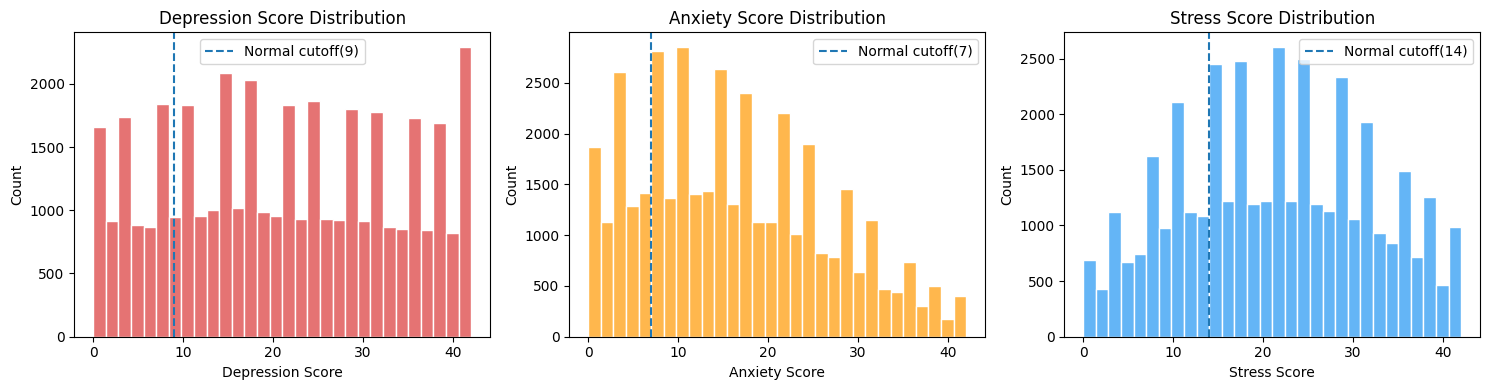

In [20]:
# 1. Depression, Anixity, Stress score distribution 
plt.figure(figsize=(15,4))

# Depression
plt.subplot(1,3,1)
plt.hist(df_1['depression_score'], bins=30, color='#E57373', edgecolor='white')
plt.axvline(9, linestyle='--', label=f'Normal cutoff(9)')
plt.legend()
plt.xlabel('Depression Score')
plt.ylabel('Count')
plt.title("Depression Score Distribution")

# Anxiety
plt.subplot(1,3,2)
plt.hist(df_1['anxiety_score'], bins=30, color='#FFB74D', edgecolor='white')
plt.axvline(7, linestyle='--', label=f'Normal cutoff(7)')
plt.legend()
plt.xlabel('Anxiety Score')
plt.ylabel('Count')
plt.title("Anxiety Score Distribution")

# Stress
plt.subplot(1,3,3)
plt.hist(df_1['stress_score'], bins=30, color='#64B5F6', edgecolor='white')
plt.axvline(14, linestyle='--', label=f'Normal cutoff(14)')
plt.legend()
plt.xlabel('Stress Score')
plt.ylabel('Count')
plt.title("Stress Score Distribution")

plt.tight_layout()
plt.show()

**Insights**
* 1. Large portion of participants fall into Mild to Moderate range and above.
* 2. Anixity distribution is slightly right-skewed.
* 3. Many individuals fall into Moderate stress category (around 15–25 range).

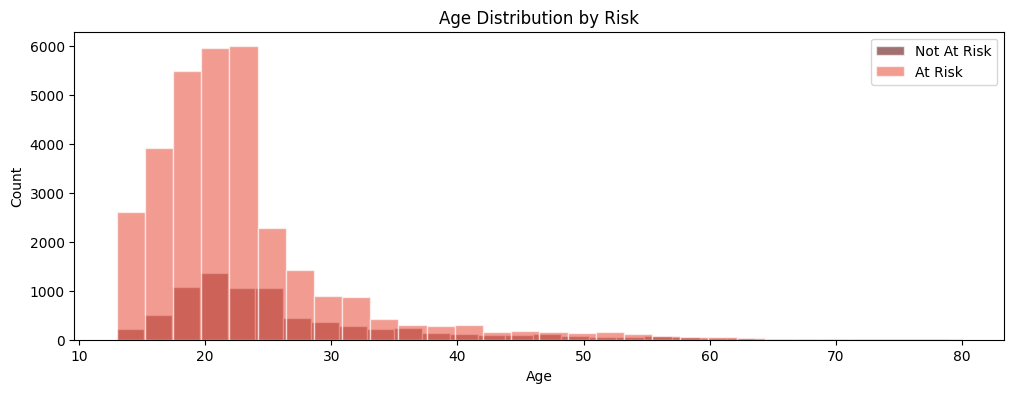

In [21]:
# 2. Age distribution by risk

plt.figure(figsize=(12,4))

plt.hist(df_1[df_1['at_risk']==0]['age'], bins=30,alpha=0.6, color="#631215", label='Not At Risk', edgecolor='white')
plt.hist(df_1[df_1['at_risk']==1]['age'], bins=30,alpha=0.6, color="#EA5848", label='At Risk', edgecolor='white')

plt.title("Age Distribution by Risk")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()

* Particpents between 18 to 25 age falls at High_Risk

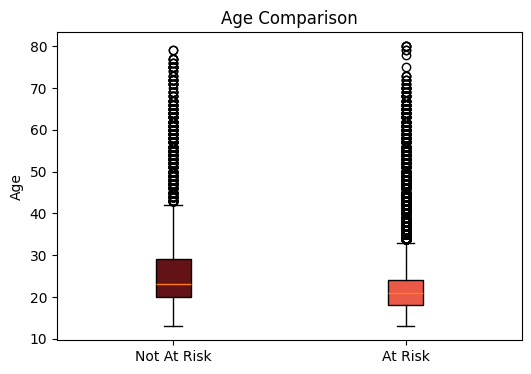

           count   mean    std   min   25%   50%   75%   max
at_risk                                                     
0         7830.0  26.31  10.40  13.0  20.0  23.0  29.0  79.0
1        31934.0  22.68   7.88  13.0  18.0  21.0  24.0  80.0


In [22]:
# Age Boxplot
plt.figure(figsize=(6,4))
plt.boxplot(df_1[df_1['at_risk']==0]['age'], positions=[1], patch_artist=True,
                          boxprops=dict(facecolor="#631215"))
plt.boxplot(df_1[df_1['at_risk']==1]['age'], positions=[2], patch_artist=True,
                          boxprops=dict(facecolor="#EA5848"))
plt.xticks([1,2], ['Not At Risk','At Risk'])
plt.ylabel("Age")
plt.title("Age Comparison")
plt.show()

# Summary statistics
print(df_1.groupby('at_risk')['age'].describe().round(2))

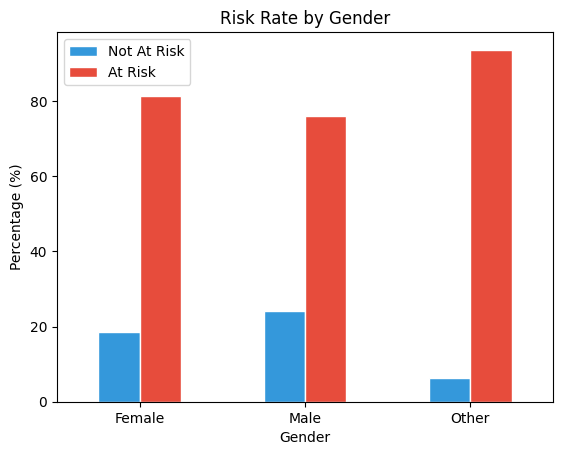

In [23]:
# 3. Gender breakdown 
df_1['gender_label'] = df_1['gender'].map({1: 'Male', 2: 'Female', 3: 'Other'})
# Gender vs at_risk
gender_risk = df_1.groupby(['gender_label', 'at_risk']).size().unstack()
gender_risk_pct = gender_risk.div(gender_risk.sum(axis=1), axis=0) * 100 # at_risk / total(not_at_risk+ at_risk)
gender_risk_pct.plot(kind='bar', color=['#3498DB', '#E74C3C'], edgecolor='white')
plt.title("Risk Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.legend(['Not At Risk', 'At Risk'])
plt.xticks(rotation=0)

plt.show()

**Insignts**
* Majority in all genders are At Risk (above 75%). Females have slightly higher risk than males.
* "Other" category shows highest risk rate (~90%+).

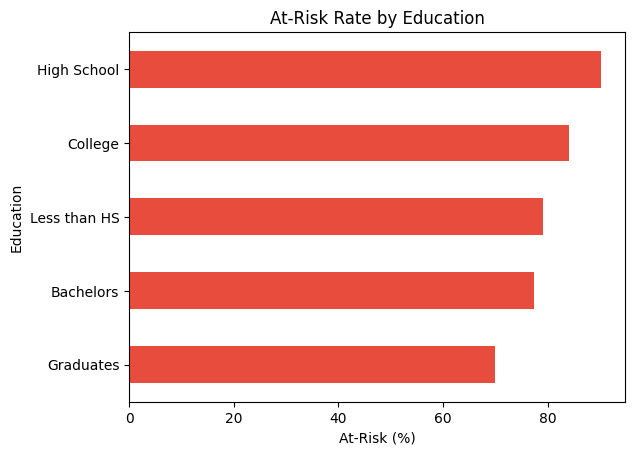

In [24]:
# Count At-Risk per education
df_1['edu_label'] = df_1['education'].map({ 0: 'Less than HS', 1: 'High School', 2: 'College', 3: 'Bachelors', 4: 'Graduates'})  #Provided in Inputs Source
edu_risk = df_1.groupby(['edu_label', 'at_risk']).size().unstack()
edu_risk_pct = edu_risk.div(edu_risk.sum(axis=1), axis=0) * 100
edu_risk_pct[1].sort_values().plot(kind='barh', color='#E74C3C')
plt.title("At-Risk Rate by Education")
plt.xlabel("At-Risk (%)")
plt.ylabel("Education")
plt.show()

* Lower education levels show higher risk rates. Graduates have relatively lower at-risk percentage.

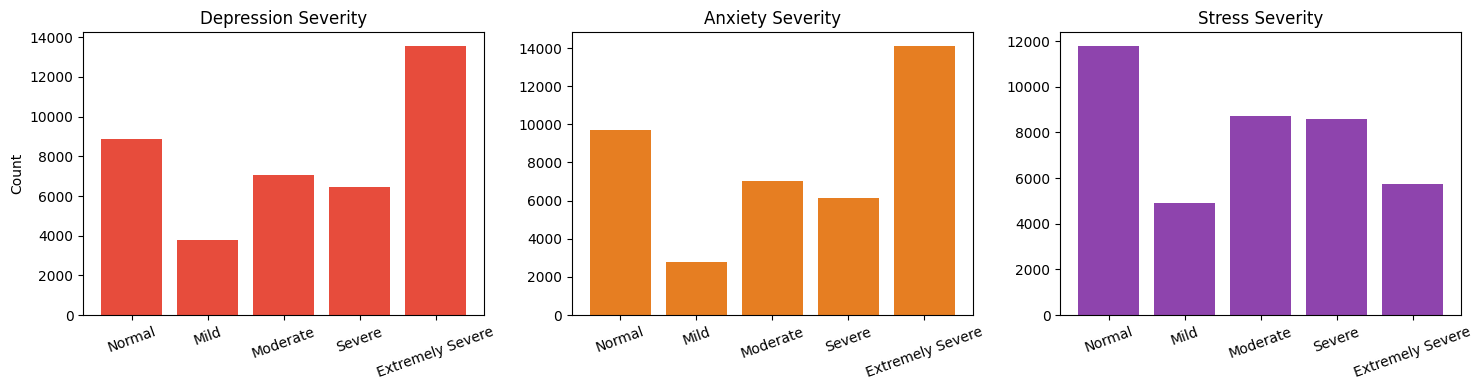

In [25]:
# Severity by at-risk
SEVERITY_LABELS = {0: 'Normal', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Extremely Severe'} # provided in indput data.
plt.figure(figsize=(15,4))

# Depression
plt.subplot(1,3,1)
counts = df_1['depression_severity'].value_counts().sort_index()
plt.bar(counts.index, counts.values, color='#E74C3C')
plt.xticks(counts.index, [SEVERITY_LABELS[i] for i in counts.index], rotation=20)
plt.title("Depression Severity")
plt.ylabel("Count")

# Anxiety
plt.subplot(1,3,2)
counts = df_1['anxiety_severity'].value_counts().sort_index()
plt.bar(counts.index, counts.values, color='#E67E22')
plt.xticks(counts.index, [SEVERITY_LABELS[i] for i in counts.index], rotation=20)
plt.title("Anxiety Severity")

# Stress
plt.subplot(1,3,3)
counts = df_1['stress_severity'].value_counts().sort_index()
plt.bar(counts.index, counts.values, color='#8E44AD')
plt.xticks(counts.index, [SEVERITY_LABELS[i] for i in counts.index], rotation=20)
plt.title("Stress Severity")

plt.tight_layout()
plt.show()

* Extremely Severe (Level 4) is highest across Depression and Anxiety.
* Stress shows slightly Normal cases compared to Depression & Anxiety.

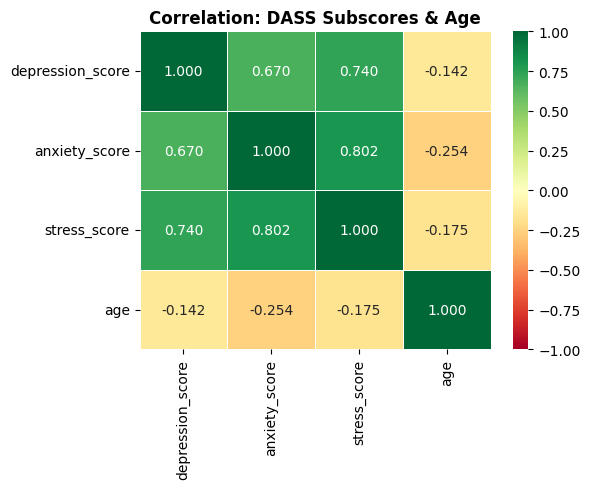

In [26]:
# Correlation heatmap of DASS scores
corr_cols = ['depression_score', 'anxiety_score', 'stress_score', 'age']
corr_matrix = df_1[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            ax=ax, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Correlation: DASS Subscores & Age', fontweight='bold')
plt.tight_layout()
#plt.savefig('plot_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

### Preprocessing & Feature Engineering


In [27]:
IMP_COLS = answer_cols + [ 'age', 'gender', 'education', 'urban','religion', 'orientation', 'race', 'married', 'familysize','at_risk']

In [28]:
df_clean = df_1[IMP_COLS].copy()
df_clean.head()

,Q1A,Q2A,Q3A,Q4A,Q5A,Q6A,Q7A,Q8A,Q9A,Q10A,Q11A,Q12A,Q13A,Q14A,Q15A,Q16A,Q17A,Q18A,Q19A,Q20A,Q21A,Q22A,Q23A,Q24A,Q25A,Q26A,Q27A,Q28A,Q29A,Q30A,Q31A,Q32A,Q33A,Q34A,Q35A,Q36A,Q37A,Q38A,Q39A,Q40A,Q41A,Q42A,age,gender,education,urban,religion,orientation,race,married,familysize,at_risk
0,3,3,1,3,3,3,3,3,1,0,3,3,3,3,3,3,2,3,2,2,0,3,3,3,3,3,3,2,3,1,3,3,1,2,3,3,0,1,3,2,3,3,16,2,2,3,12,1,10,1,2,1
1,3,0,1,2,3,3,2,3,2,1,1,1,3,3,2,2,3,1,0,0,1,2,0,1,1,2,2,3,2,2,1,2,2,1,1,2,3,1,1,0,1,1,16,2,2,3,7,0,70,1,4,1
2,2,0,3,0,3,2,0,2,1,3,1,0,3,0,3,3,3,1,1,0,3,2,1,3,1,0,1,0,1,1,3,2,0,3,2,3,3,3,1,1,0,3,17,2,2,3,4,3,60,1,3,1
3,1,2,1,0,2,2,3,1,2,2,1,0,0,3,1,1,2,0,0,1,0,0,0,0,0,1,3,0,2,2,2,0,1,3,0,0,1,0,2,3,3,1,13,2,1,3,4,5,70,1,5,1
4,1,1,2,3,3,1,3,3,3,2,1,3,3,3,3,2,3,3,3,3,2,2,3,1,3,3,1,3,1,3,2,3,3,3,2,3,2,2,2,3,3,2,19,2,3,2,10,1,10,1,4,1


In [29]:
# Age bins (for fairness analysis later)
df_clean['age_bin'] = pd.cut(df_clean['age'], bins=[0, 17, 24, 34, 44, 54, 80],
                       labels=['1', '2', '3', '4', '5', '6'])
df_clean['age_bin'] = df_clean['age_bin'].astype(str)   # convert to string for encoder


In [30]:
df_clean.drop('age', axis=1, inplace=True)

In [31]:
df_clean = df_clean.drop_duplicates()
len(df_clean)

39756

In [32]:
df_clean.head()

,Q1A,Q2A,Q3A,Q4A,Q5A,Q6A,Q7A,Q8A,Q9A,Q10A,Q11A,Q12A,Q13A,Q14A,Q15A,Q16A,Q17A,Q18A,Q19A,Q20A,Q21A,Q22A,Q23A,Q24A,Q25A,Q26A,Q27A,Q28A,Q29A,Q30A,Q31A,Q32A,Q33A,Q34A,Q35A,Q36A,Q37A,Q38A,Q39A,Q40A,Q41A,Q42A,gender,education,urban,religion,orientation,race,married,familysize,at_risk,age_bin
0,3,3,1,3,3,3,3,3,1,0,3,3,3,3,3,3,2,3,2,2,0,3,3,3,3,3,3,2,3,1,3,3,1,2,3,3,0,1,3,2,3,3,2,2,3,12,1,10,1,2,1,1
1,3,0,1,2,3,3,2,3,2,1,1,1,3,3,2,2,3,1,0,0,1,2,0,1,1,2,2,3,2,2,1,2,2,1,1,2,3,1,1,0,1,1,2,2,3,7,0,70,1,4,1,1
2,2,0,3,0,3,2,0,2,1,3,1,0,3,0,3,3,3,1,1,0,3,2,1,3,1,0,1,0,1,1,3,2,0,3,2,3,3,3,1,1,0,3,2,2,3,4,3,60,1,3,1,1
3,1,2,1,0,2,2,3,1,2,2,1,0,0,3,1,1,2,0,0,1,0,0,0,0,0,1,3,0,2,2,2,0,1,3,0,0,1,0,2,3,3,1,2,1,3,4,5,70,1,5,1,1
4,1,1,2,3,3,1,3,3,3,2,1,3,3,3,3,2,3,3,3,3,2,2,3,1,3,3,1,3,1,3,2,3,3,3,2,3,2,2,2,3,3,2,2,3,2,10,1,10,1,4,1,2


In [33]:
X = df_clean.drop('at_risk', axis=1)
y = df_clean['at_risk']

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [35]:
print(X_scaled)

[[ 1.33783329  1.64459033 -0.21756363 ... -0.3577696  -0.73843354
  -1.2511196 ]
 [ 1.33783329 -1.05466792 -0.21756363 ... -0.3577696   0.2414778
  -1.2511196 ]
 [ 0.36880783 -1.05466792  1.7086049  ... -0.3577696  -0.24847787
  -1.2511196 ]
 ...
 [-0.60021762 -1.05466792 -0.21756363 ...  1.88568282 -0.24847787
   2.77156672]
 [ 0.36880783 -1.05466792 -0.21756363 ... -0.3577696  -0.73843354
  -0.24544802]
 [-0.60021762 -1.05466792 -0.21756363 ... -0.3577696   0.2414778
   0.76022356]]


In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f'x_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'x_test: {X_test.shape}, y_test: {y_test.shape}')

x_train: (29817, 51), y_train: (29817,)
x_test: (9939, 51), y_test: (9939,)


In [37]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

### Model Training for  Binary classification prediction (At_risk, Not_at_risk) 

#### Logistic regression for Binary classification prediction (At_risk, Not_at_risk)

In [38]:

# LR traing for binary classification target
model = LogisticRegression(random_state=42,max_iter=1000)
model.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [39]:
# Predict
y_pred_LR = model.predict(X_test)
confusion_matrix(y_test, y_pred_LR)

array([[1783,  189],
       [ 172, 7795]])

In [40]:
print(classification_report(y_test, y_pred_LR))
print(accuracy_score(y_test, y_pred_LR)*100)

              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1972
           1       0.98      0.98      0.98      7967

    accuracy                           0.96      9939
   macro avg       0.94      0.94      0.94      9939
weighted avg       0.96      0.96      0.96      9939

96.36784384746957


* with Logistic Regression model i got accuracy which tends to higher side. So I implementing another approch which is speration of dataset into Depression, anxiety, stress as multiclass classification.

### Reusable Helper Function

In [42]:
# Reusable Function
def train_and_evaluate(model, model_name, X_train, y_train, X_test, y_test):
    # Train
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"\nModel     : {model_name}")
    print(f"Accuracy  : {acc:.3f}")
    print(f"F1-Score  : {f1:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    
    target_names = [SEVERITY_LABELS[i] for i in sorted(y_test.unique())]
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    return acc, f1, precision, recall

###  DEPRESSION Models - Multiclass classification

####  Prepare Depression Dataset

In [43]:
X_dep = df_1[depression_cols + demographics].copy() # Features: Depression questions + demographics
y_dep = df_1['depression_severity'].copy()          # Target  : depression_severity (0=Normal to 4=Extremely Severe)

print(f'X shape: {X_dep.shape}')
print(y_dep.map(SEVERITY_LABELS).value_counts())

X shape: (39764, 25)
depression_severity
Extremely Severe    13572
Normal               8853
Moderate             7077
Severe               6477
Mild                 3785
Name: count, dtype: int64


In [44]:
# Split
X_dep_train, X_dep_test, y_dep_train, y_dep_test = train_test_split(
    X_dep, y_dep, test_size=0.3, random_state=42, stratify=y_dep)

# SMOTE
smote = SMOTE(random_state=42)
X_dep_train_smote, y_dep_train_smote = smote.fit_resample(X_dep_train, y_dep_train)

# Scale features 
scaler_dep = StandardScaler()
X_dep_train_scaled = scaler_dep.fit_transform(X_dep_train_smote)
X_dep_test_scaled  = scaler_dep.transform(X_dep_test)

print(f'Train size (after SMOTE): {X_dep_train_scaled.shape[0]}')
print(f'Test  size: {X_dep_test_scaled.shape[0]}')
print(pd.Series(y_dep_train_smote).map(SEVERITY_LABELS).value_counts())

Train size (after SMOTE): 47500
Test  size: 11930
depression_severity
Severe              9500
Extremely Severe    9500
Moderate            9500
Mild                9500
Normal              9500
Name: count, dtype: int64


#### Model 1 - Logistic Regression

In [45]:
# LR Model Define & Train
dep_LR = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
acc_dep_LR, f1_dep_LR, prec_dep_LR, rec_dep_LR = train_and_evaluate(dep_LR, "Logistic Regression",
    X_dep_train_scaled, y_dep_train_smote,
    X_dep_test_scaled, y_dep_test)


Model     : Logistic Regression
Accuracy  : 0.881
F1-Score  : 0.883
Precision : 0.896
Recall    : 0.881

Classification Report:
                  precision    recall  f1-score   support

          Normal       1.00      0.77      0.87      2656
            Mild       0.56      0.68      0.61      1136
        Moderate       0.82      0.79      0.81      2123
          Severe       0.81      1.00      0.90      1943
Extremely Severe       1.00      1.00      1.00      4072

        accuracy                           0.88     11930
       macro avg       0.84      0.85      0.84     11930
    weighted avg       0.90      0.88      0.88     11930

Confusion Matrix:
[[2043  613    0    0    0]
 [   0  774  362    0    0]
 [   0    0 1678  445    0]
 [   0    0    0 1943    0]
 [   0    0    0    0 4072]]


#### Model 2 - Decision Tree

In [46]:
dep_DT = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)
acc_dep_DT, f1_dep_DT, prec_dep_DT, rec_dep_DT = train_and_evaluate(dep_DT, "Logistic Regression",
    X_dep_train_scaled, y_dep_train_smote,
    X_dep_test_scaled, y_dep_test)


Model     : Logistic Regression
Accuracy  : 0.660
F1-Score  : 0.674
Precision : 0.718
Recall    : 0.660

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.94      0.59      0.72      2656
            Mild       0.29      0.39      0.34      1136
        Moderate       0.51      0.47      0.49      2123
          Severe       0.47      0.74      0.57      1943
Extremely Severe       0.92      0.85      0.88      4072

        accuracy                           0.66     11930
       macro avg       0.63      0.61      0.60     11930
    weighted avg       0.72      0.66      0.67     11930

Confusion Matrix:
[[1555  853  226   22    0]
 [  85  447  501  103    0]
 [  18  204  999  884   18]
 [   0   13  216 1434  280]
 [   0    0   10  620 3442]]


#### Model 3 - K-Nearest Neighborsm

In [47]:
dep_KNN = KNeighborsClassifier(n_neighbors=15)
acc_dep_KNN, f1_dep_KNN, prec_dep_KNN, rec_dep_KNN  = train_and_evaluate(dep_KNN, "KNN",
    X_dep_train_scaled, y_dep_train_smote,
    X_dep_test_scaled, y_dep_test)


Model     : KNN
Accuracy  : 0.846
F1-Score  : 0.850
Precision : 0.863
Recall    : 0.846

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.97      0.79      0.87      2656
            Mild       0.52      0.65      0.58      1136
        Moderate       0.79      0.73      0.76      2123
          Severe       0.74      0.93      0.82      1943
Extremely Severe       0.98      0.95      0.97      4072

        accuracy                           0.85     11930
       macro avg       0.80      0.81      0.80     11930
    weighted avg       0.86      0.85      0.85     11930

Confusion Matrix:
[[2098  555    3    0    0]
 [  65  740  331    0    0]
 [   0  119 1560  444    0]
 [   0    0   70 1804   69]
 [   0    0    0  185 3887]]


#### Ensemble Model 4 - Random Forest

In [48]:
dep_RF = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
acc_dep_RF, f1_dep_RF, prec_dep_RF, rec_dep_RF  = train_and_evaluate(dep_RF, "Random Forest",
    X_dep_train_scaled, y_dep_train_smote,
    X_dep_test_scaled, y_dep_test)


Model     : Random Forest
Accuracy  : 0.827
F1-Score  : 0.832
Precision : 0.854
Recall    : 0.827

Classification Report:
                  precision    recall  f1-score   support

          Normal       1.00      0.72      0.83      2656
            Mild       0.48      0.63      0.54      1136
        Moderate       0.77      0.72      0.74      2123
          Severe       0.71      0.93      0.81      1943
Extremely Severe       0.98      0.96      0.97      4072

        accuracy                           0.83     11930
       macro avg       0.79      0.79      0.78     11930
    weighted avg       0.85      0.83      0.83     11930

Confusion Matrix:
[[1900  754    2    0    0]
 [   8  720  408    0    0]
 [   0   34 1522  567    0]
 [   0    0   46 1814   83]
 [   0    0    0  166 3906]]


#### Ensemble Model 5 - XGBoost

In [49]:
dep_XGB = XGBClassifier(n_estimators=100, max_depth=4, subsample=0.8, learning_rate=0.1,
                        eval_metric='mlogloss', random_state=42)
acc_dep_XGB, f1_dep_XGB, prec_dep_XGB, rec_dep_XGB = train_and_evaluate(dep_XGB, "XGBoost",
                                                     X_dep_train_scaled, y_dep_train_smote,
                                                     X_dep_test_scaled, y_dep_test)


Model     : XGBoost
Accuracy  : 0.850
F1-Score  : 0.853
Precision : 0.868
Recall    : 0.850

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.99      0.75      0.86      2656
            Mild       0.51      0.61      0.56      1136
        Moderate       0.78      0.76      0.77      2123
          Severe       0.76      0.95      0.85      1943
Extremely Severe       0.99      0.98      0.98      4072

        accuracy                           0.85     11930
       macro avg       0.81      0.81      0.80     11930
    weighted avg       0.87      0.85      0.85     11930

Confusion Matrix:
[[2000  656    0    0    0]
 [  17  698  421    0    0]
 [   1   18 1621  483    0]
 [   0    0   36 1848   59]
 [   0    0    0   96 3976]]


#### Deperation models Results

In [50]:
print(f"Logistic Regression: Accuracy={acc_dep_LR:.3f}, F1={f1_dep_LR:.3f},'Precision'={prec_dep_LR:.3f}, 'Recall'={rec_dep_LR:.3f}")
print(f"Decision Tree      : Accuracy={acc_dep_DT:.3f}, F1={f1_dep_DT:.3f},'Precision'={prec_dep_DT:.3f}, 'Recall'={rec_dep_DT:.3f}")
print(f"KNN                : Accuracy={acc_dep_KNN:.3f}, F1={f1_dep_KNN:.3f},'Precision'={prec_dep_KNN:.3f}, 'Recall'={rec_dep_KNN:.3f}")
print(f"Random Forest      : Accuracy={acc_dep_RF:.3f}, F1={f1_dep_RF:.3f},'Precision'={prec_dep_RF:.3f}, 'Recall'={rec_dep_RF:.3f}")
print(f"XGBoost            : Accuracy={acc_dep_XGB:.3f}, F1={f1_dep_XGB:.3f},'Precision'={prec_dep_XGB:.3f}, 'Recall'={rec_dep_XGB:.3f}")


Logistic Regression: Accuracy=0.881, F1=0.883,'Precision'=0.896, 'Recall'=0.881
Decision Tree      : Accuracy=0.660, F1=0.674,'Precision'=0.718, 'Recall'=0.660
KNN                : Accuracy=0.846, F1=0.850,'Precision'=0.863, 'Recall'=0.846
Random Forest      : Accuracy=0.827, F1=0.832,'Precision'=0.854, 'Recall'=0.827
XGBoost            : Accuracy=0.850, F1=0.853,'Precision'=0.868, 'Recall'=0.850


* Best Depression Model : Logistic Regression (Accuracy=0.881, F1=0.883)

###  ANXIETY Models - Multiclass classification

#### Prepare Anxiety Dataset

In [51]:
X_anx = df_1[anxiety_cols + demographics].copy()
y_anx = df_1['anxiety_severity'].copy()

print(f'X shape: {X_anx.shape}')
print(y_anx.map(SEVERITY_LABELS).value_counts())

X shape: (39764, 25)
anxiety_severity
Extremely Severe    14118
Normal               9723
Moderate             7047
Severe               6112
Mild                 2764
Name: count, dtype: int64


In [52]:
# Split
X_anx_train, X_anx_test, y_anx_train, y_anx_test = train_test_split(
    X_anx, y_anx, test_size=0.3, random_state=42, stratify=y_anx)

# SMOTE
smote = SMOTE(random_state=42)
X_anx_train_res, y_anx_train_res = smote.fit_resample(X_anx_train, y_anx_train)

# Scale features 
scaler_anx = StandardScaler()
X_anx_train_scaled = scaler_anx.fit_transform(X_anx_train_res)
X_anx_test_scaled  = scaler_anx.transform(X_anx_test)

print(f'Train size (after SMOTE): {X_anx_train_scaled.shape[0]}')
print(f'Test  size : {X_anx_test_scaled.shape[0]}')
print(pd.Series(y_anx_train_res).map(SEVERITY_LABELS).value_counts())

Train size (after SMOTE): 49410
Test  size : 11930
anxiety_severity
Extremely Severe    9882
Severe              9882
Moderate            9882
Normal              9882
Mild                9882
Name: count, dtype: int64


#### Model 1 - Logistic Regression

In [53]:
anx_LR = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
acc_anx_LR, f1_anx_LR, prec_anx_LR, rec_anx_LR = train_and_evaluate(anx_LR, "Logistic Regression",
    X_anx_train_scaled, y_anx_train_res,
    X_anx_test_scaled, y_anx_test)


Model     : Logistic Regression
Accuracy  : 0.823
F1-Score  : 0.830
Precision : 0.860
Recall    : 0.823

Classification Report:
                  precision    recall  f1-score   support

          Normal       1.00      0.68      0.81      2917
            Mild       0.26      0.39      0.31       829
        Moderate       0.74      0.68      0.71      2114
          Severe       0.73      1.00      0.84      1834
Extremely Severe       1.00      1.00      1.00      4236

        accuracy                           0.82     11930
       macro avg       0.75      0.75      0.73     11930
    weighted avg       0.86      0.82      0.83     11930

Confusion Matrix:
[[1995  919    3    0    0]
 [   1  325  503    0    0]
 [   0    0 1429  685    0]
 [   0    0    2 1832    0]
 [   0    0    0    0 4236]]


#### Model 2 - Decision Tree

In [54]:
anx_model_DT = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)

acc_anx_DT, f1_anx_DT, prec_anx_DT, rec_anx_DT = train_and_evaluate(anx_model_DT, "Decision Tree",
    X_anx_train_scaled, y_anx_train_res,
    X_anx_test_scaled, y_anx_test)


Model     : Decision Tree
Accuracy  : 0.599
F1-Score  : 0.623
Precision : 0.682
Recall    : 0.599

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.86      0.67      0.75      2917
            Mild       0.18      0.27      0.22       829
        Moderate       0.43      0.33      0.37      2114
          Severe       0.35      0.68      0.46      1834
Extremely Severe       0.92      0.72      0.81      4236

        accuracy                           0.60     11930
       macro avg       0.55      0.53      0.52     11930
    weighted avg       0.68      0.60      0.62     11930

Confusion Matrix:
[[1947  591  269  110    0]
 [ 166  222  272  168    1]
 [ 127  317  688  955   27]
 [  12   72  283 1243  224]
 [   0    8   96 1086 3046]]


#### Model 3 - K-Nearest Neighborsm

In [55]:
anx_knn = KNeighborsClassifier(n_neighbors=15)
acc_anx_knn, f1_anx_knn,  prec_anx_knn, rec_anx_knn = train_and_evaluate( anx_knn, 'K-Nearest Neighbors',
        X_anx_train_scaled,y_anx_train_res,
        X_anx_test_scaled, y_anx_test)


Model     : K-Nearest Neighbors
Accuracy  : 0.780
F1-Score  : 0.792
Precision : 0.822
Recall    : 0.780

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.91      0.77      0.84      2917
            Mild       0.33      0.58      0.42       829
        Moderate       0.74      0.55      0.63      2114
          Severe       0.62      0.85      0.72      1834
Extremely Severe       0.99      0.91      0.94      4236

        accuracy                           0.78     11930
       macro avg       0.72      0.73      0.71     11930
    weighted avg       0.82      0.78      0.79     11930

Confusion Matrix:
[[2258  634   25    0    0]
 [ 170  483  174    2    0]
 [  48  342 1171  553    0]
 [   0    1  215 1561   57]
 [   0    1    3  395 3837]]


#### Ensemble Model 4 - Random Forest

In [56]:
anx_RF = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42)
acc_anx_RF, f1_anx_RF, prec_anx_RF, rec_anx_RF = train_and_evaluate( anx_RF, 'Random Forest',
        X_anx_train_scaled,y_anx_train_res,
        X_anx_test_scaled, y_anx_test)


Model     : Random Forest
Accuracy  : 0.745
F1-Score  : 0.756
Precision : 0.802
Recall    : 0.745

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.99      0.62      0.76      2917
            Mild       0.24      0.39      0.29       829
        Moderate       0.64      0.53      0.58      2114
          Severe       0.58      0.89      0.70      1834
Extremely Severe       0.97      0.94      0.95      4236

        accuracy                           0.74     11930
       macro avg       0.68      0.68      0.66     11930
    weighted avg       0.80      0.74      0.76     11930

Confusion Matrix:
[[1808  997  112    0    0]
 [  19  324  479    7    0]
 [   6   55 1121  932    0]
 [   0    0   52 1641  141]
 [   0    0    0  245 3991]]


#### Ensemble Model 5 - XGboost

In [57]:
anx_XGB = XGBClassifier(n_estimators=100, max_depth=4, subsample=0.8, learning_rate=0.1,
                        eval_metric='mlogloss', random_state=42)
acc_anx_XGB, f1_anx_XGB, prec_anx_XGB, rec_anx_XGB = train_and_evaluate(anx_XGB, 'XGBoost',
                                                         X_anx_train_scaled, y_anx_train_res,
                                                          X_anx_test_scaled, y_anx_test)



Model     : XGBoost
Accuracy  : 0.778
F1-Score  : 0.787
Precision : 0.820
Recall    : 0.778

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.98      0.69      0.81      2917
            Mild       0.26      0.38      0.31       829
        Moderate       0.67      0.57      0.62      2114
          Severe       0.62      0.93      0.74      1834
Extremely Severe       0.98      0.96      0.97      4236

        accuracy                           0.78     11930
       macro avg       0.70      0.70      0.69     11930
    weighted avg       0.82      0.78      0.79     11930

Confusion Matrix:
[[2003  856   58    0    0]
 [  37  314  475    3    0]
 [   3   40 1206  865    0]
 [   0    0   61 1699   74]
 [   0    0    0  174 4062]]


#### Anxiety Model Result

In [58]:
print("-" * 72)
print(f"Logistic Regression: Accuracy={acc_anx_LR:.3f}, F1={f1_anx_LR:.3f},'Precision'={prec_anx_LR:.3f}, 'Recall'={rec_anx_LR:.3f}")
print(f"Decision Tree      : Accuracy={acc_anx_DT:.3f}, F1={f1_anx_DT:.3f},'Precision'={prec_anx_DT:.3f}, 'Recall'={rec_anx_DT:.3f}")
print(f"KNN                : Accuracy={acc_anx_knn:.3f}, F1={f1_anx_knn:.3f},'Precision'={prec_anx_knn:.3f}, 'Recall'={rec_anx_knn:.3f}")
print(f"Random Forest      : Accuracy={acc_anx_RF:.3f}, F1={f1_anx_RF:.3f},'Precision'={prec_anx_RF:.3f}, 'Recall'={rec_anx_RF:.3f}")
print(f"Gradient Boosting  : Accuracy={acc_anx_XGB:.3f}, F1={f1_anx_XGB:.3f},'Precision'={prec_anx_XGB:.3f}, 'Recall'={rec_anx_XGB:.3f}")

------------------------------------------------------------------------
Logistic Regression: Accuracy=0.823, F1=0.830,'Precision'=0.860, 'Recall'=0.823
Decision Tree      : Accuracy=0.599, F1=0.623,'Precision'=0.682, 'Recall'=0.599
KNN                : Accuracy=0.780, F1=0.792,'Precision'=0.822, 'Recall'=0.780
Random Forest      : Accuracy=0.745, F1=0.756,'Precision'=0.802, 'Recall'=0.745
Gradient Boosting  : Accuracy=0.778, F1=0.787,'Precision'=0.820, 'Recall'=0.778


* Best Depression Model : Logistic Regression (Accuracy=0.823, F1=0.830)

### Stress Models - Multiclass classification

#### Prepare Stress Dataset

In [59]:
X_str = df_1[stress_cols + demographics].copy()
y_str = df_1['stress_severity'].copy()

print(f'X shape: {X_str.shape}')
print(y_str.map(SEVERITY_LABELS).value_counts())

X shape: (39764, 25)
stress_severity
Normal              11794
Moderate             8730
Severe               8572
Extremely Severe     5747
Mild                 4921
Name: count, dtype: int64


In [60]:
# Split
X_str_train, X_str_test, y_str_train, y_str_test = train_test_split(
    X_str, y_str, test_size=0.3, random_state=42, stratify=y_str)

smote = SMOTE(random_state=42)
X_str_train_res, y_str_train_res = smote.fit_resample(X_str_train, y_str_train)

scaler_str = StandardScaler()
X_str_train_scaled = scaler_str.fit_transform(X_str_train_res)
X_str_test_scaled  = scaler_str.transform(X_str_test)

print(f'Train size (after SMOTE): {X_str_train_scaled.shape[0]}')
print(f'Test  size : {X_str_test_scaled.shape[0]}')
print(pd.Series(y_str_train_res).map(SEVERITY_LABELS).value_counts())

Train size (after SMOTE): 41275
Test  size : 11930
stress_severity
Extremely Severe    8255
Moderate            8255
Severe              8255
Normal              8255
Mild                8255
Name: count, dtype: int64


#### Model 1 - Logistic Regression

In [61]:
str_LR = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
acc_str_LR, f1_str_LR, prec_str_LR, rec_str_LR  = train_and_evaluate(str_LR, "Logistic Regression",
    X_str_train_scaled, y_str_train_res,
    X_str_test_scaled, y_str_test)


Model     : Logistic Regression
Accuracy  : 0.871
F1-Score  : 0.873
Precision : 0.884
Recall    : 0.871

Classification Report:
                  precision    recall  f1-score   support

          Normal       1.00      0.82      0.90      3539
            Mild       0.64      0.78      0.70      1476
        Moderate       0.88      0.88      0.88      2619
          Severe       0.88      0.90      0.89      2572
Extremely Severe       0.87      1.00      0.93      1724

        accuracy                           0.87     11930
       macro avg       0.85      0.88      0.86     11930
    weighted avg       0.88      0.87      0.87     11930

Confusion Matrix:
[[2887  652    0    0    0]
 [   8 1146  322    0    0]
 [   0    0 2311  308    0]
 [   0    0    0 2318  254]
 [   0    0    0    0 1724]]


#### Model 2 - Decision Tree

In [62]:
str_DT = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)
acc_str_DT, f1_str_DT, prec_str_DT, rec_str_DT  = train_and_evaluate(str_DT, "Decision Tree",
    X_str_train_scaled, y_str_train_res,
    X_str_test_scaled, y_str_test)


Model     : Decision Tree
Accuracy  : 0.603
F1-Score  : 0.618
Precision : 0.662
Recall    : 0.603

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.93      0.59      0.72      3539
            Mild       0.31      0.52      0.38      1476
        Moderate       0.51      0.54      0.53      2619
          Severe       0.59      0.59      0.59      2572
Extremely Severe       0.76      0.80      0.78      1724

        accuracy                           0.60     11930
       macro avg       0.62      0.61      0.60     11930
    weighted avg       0.66      0.60      0.62     11930

Confusion Matrix:
[[2103 1195  234    7    0]
 [ 140  763  527   46    0]
 [  28  492 1422  659   18]
 [   2   48  570 1530  422]
 [   0    0   13  337 1374]]


#### Model 3 - KNN

In [63]:
str_knn = KNeighborsClassifier(n_neighbors=15)
acc_str_knn, f1_str_knn, prec_str_knn, rec_str_knn  = train_and_evaluate(str_knn, "KNN",
    X_str_train_scaled, y_str_train_res,
    X_str_test_scaled, y_str_test)


Model     : KNN
Accuracy  : 0.776
F1-Score  : 0.783
Precision : 0.816
Recall    : 0.776

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.96      0.72      0.82      3539
            Mild       0.48      0.77      0.59      1476
        Moderate       0.86      0.74      0.79      2619
          Severe       0.82      0.74      0.78      2572
Extremely Severe       0.75      1.00      0.86      1724

        accuracy                           0.78     11930
       macro avg       0.77      0.79      0.77     11930
    weighted avg       0.82      0.78      0.78     11930

Confusion Matrix:
[[2563  974    2    0    0]
 [ 114 1135  227    0    0]
 [   2  258 1935  423    1]
 [   0    0   98 1914  560]
 [   0    0    0    8 1716]]


#### Model 4 - Random Forest

In [64]:
str_RF = RandomForestClassifier(n_estimators=100, max_depth=10,
                                 min_samples_leaf=5, random_state=42)
acc_str_RF, f1_str_RF, prec_str_RF, rec_str_RF  = train_and_evaluate(str_RF, "Random Forest",
    X_str_train_scaled, y_str_train_res,
    X_str_test_scaled, y_str_test)


Model     : Random Forest
Accuracy  : 0.813
F1-Score  : 0.818
Precision : 0.835
Recall    : 0.813

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.98      0.76      0.86      3539
            Mild       0.51      0.67      0.58      1476
        Moderate       0.79      0.81      0.80      2619
          Severe       0.84      0.86      0.85      2572
Extremely Severe       0.87      0.98      0.92      1724

        accuracy                           0.81     11930
       macro avg       0.80      0.82      0.80     11930
    weighted avg       0.84      0.81      0.82     11930

Confusion Matrix:
[[2689  844    6    0    0]
 [  39  988  449    0    0]
 [   2  101 2112  404    0]
 [   0    0   97 2224  251]
 [   0    0    0   34 1690]]


#### Model 5 - XGBoost

In [65]:
str_XGB = XGBClassifier(n_estimators=100, max_depth=4, subsample=0.8,learning_rate=0.1,
                        eval_metric='mlogloss', random_state=42)
acc_str_XGB, f1_str_XGB, prec_str_XGB, rec_str_XGB = train_and_evaluate(str_XGB, "XGBoost",
    X_str_train_scaled, y_str_train_res,
    X_str_test_scaled, y_str_test)



Model     : XGBoost
Accuracy  : 0.838
F1-Score  : 0.841
Precision : 0.852
Recall    : 0.838

Classification Report:
                  precision    recall  f1-score   support

          Normal       0.98      0.80      0.88      3539
            Mild       0.57      0.68      0.62      1476
        Moderate       0.82      0.82      0.82      2619
          Severe       0.84      0.89      0.87      2572
Extremely Severe       0.88      0.99      0.94      1724

        accuracy                           0.84     11930
       macro avg       0.82      0.84      0.83     11930
    weighted avg       0.85      0.84      0.84     11930

Confusion Matrix:
[[2827  711    1    0    0]
 [  44 1011  421    0    0]
 [   0   45 2157  417    0]
 [   0    0   56 2290  226]
 [   0    0    0   12 1712]]


#### Stess Models Result

In [66]:
str_results = print(f"Logistic Regression: Accuracy={acc_str_LR:.3f}, F1={f1_str_LR:.3f},'Precision'={prec_str_LR:.3f}, 'Recall'={rec_str_LR:.3f}")
print(f"Decision Tree      : Accuracy={acc_str_DT:.3f}, F1={f1_str_DT:.3f},'Precision'={prec_str_DT:.3f}, 'Recall'={rec_str_DT:.3f}")
print(f"KNN                : Accuracy={acc_str_knn:.3f}, F1={f1_str_knn:.3f},'Precision'={prec_str_knn:.3f}, 'Recall'={rec_str_knn:.3f}")
print(f"Random Forest      : Accuracy={acc_str_RF:.3f}, F1={f1_str_RF:.3f},'Precision'={prec_str_RF:.3f}, 'Recall'={rec_str_RF:.3f}")
print(f"Gradient Boosting  : Accuracy={acc_str_XGB:.3f}, F1={f1_str_XGB:.3f},'Precision'={prec_str_XGB:.3f}, 'Recall'={rec_str_XGB:.3f}")


Logistic Regression: Accuracy=0.871, F1=0.873,'Precision'=0.884, 'Recall'=0.871
Decision Tree      : Accuracy=0.603, F1=0.618,'Precision'=0.662, 'Recall'=0.603
KNN                : Accuracy=0.776, F1=0.783,'Precision'=0.816, 'Recall'=0.776
Random Forest      : Accuracy=0.813, F1=0.818,'Precision'=0.835, 'Recall'=0.813
Gradient Boosting  : Accuracy=0.838, F1=0.841,'Precision'=0.852, 'Recall'=0.838


### Overfitting Check (for Best Model)

In [67]:
# Function to check overfitting
def check_overfitting(model, X_train, y_train, X_test, y_test, model_name="Model"):
    
    model.fit(X_train, y_train)    
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    print(f"{model_name}")
    print("Training Accuracy :", round(train_acc, 3))
    print("Testing Accuracy  :", round(test_acc, 3))
    
    if train_acc - test_acc > 0.05:
        print("Model may be Overfitting")
    else:
        print("No major Overfitting")

In [68]:
# Depression
check_overfitting(dep_LR,
                  X_dep_train_scaled, y_dep_train_smote,
                  X_dep_test_scaled, y_dep_test,
                  model_name="Best Depression Logistic Regression")
print("-" * 72)
# Anxiety
check_overfitting(anx_LR,
                  X_anx_train_scaled, y_anx_train_res,
                  X_anx_test_scaled, y_anx_test,
                  model_name="Best Anxiety Logistic Regression")
print("-" * 72)
# Stress
check_overfitting(str_LR,
                  X_str_train_scaled, y_str_train_res,
                  X_str_test_scaled, y_str_test,
                  model_name="Best Stress Logistic Regression")

Best Depression Logistic Regression
Training Accuracy : 0.878
Testing Accuracy  : 0.881
No major Overfitting
------------------------------------------------------------------------
Best Anxiety Logistic Regression
Training Accuracy : 0.801
Testing Accuracy  : 0.823
No major Overfitting
------------------------------------------------------------------------
Best Stress Logistic Regression
Training Accuracy : 0.849
Testing Accuracy  : 0.871
No major Overfitting


### Cross Validation (Model Stability)

In [69]:
def cross_validation_check(model, X_train, y_train, model_name="Model"):

    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=5, scoring='f1_macro')
    print(f"\n {model_name}")
    print("CV Scores :", np.round(cv_scores, 3))
    print("Mean CV   :", round(cv_scores.mean(), 3))
    print("Std Dev   :", round(cv_scores.std(), 3))
    
    if cv_scores.std() < 0.03:
        print("Model is Stable")
    else:
        print("Model Variance is High")

In [70]:
cross_validation_check(dep_LR, X_dep_train_scaled, y_dep_train_smote, "Best Depression model LR")
cross_validation_check(anx_LR, X_anx_train_scaled, y_anx_train_res, "Best Anxiety model LR")
cross_validation_check(str_LR, X_str_train_scaled, y_str_train_res, "Best Stress stress LR")


 Best Depression model LR
CV Scores : [0.803 0.857 0.867 0.867 0.871]
Mean CV   : 0.853
Std Dev   : 0.026
Model is Stable

 Best Anxiety model LR
CV Scores : [0.618 0.813 0.786 0.78  0.803]
Mean CV   : 0.76
Std Dev   : 0.072
Model Variance is High

 Best Stress stress LR
CV Scores : [0.845 0.85  0.858 0.833 0.716]
Mean CV   : 0.82
Std Dev   : 0.053
Model Variance is High


* CV standard deviation for Anxiety is 0.072, indicating higher variance across folds. This is due to sensitivity to data distribution. I handle this using regularization tuning, class balancing in hyperparmeter tunning.

### Multicollinearity Check for LR

In [71]:
def check_vif(X_train_scaled, X_original, model_name="Model"):
    
    import pandas as pd
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    # Automatically extract column names
    X_df = pd.DataFrame(X_train_scaled, columns=X_original.columns)
    
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_df.columns
    vif_data["VIF"] = [variance_inflation_factor(X_df.values, i)
                       for i in range(X_df.shape[1])]

    vif_data = vif_data.sort_values(by="VIF", ascending=False)
    print(f"\n Top Multicollinearity - {model_name}")
    print(vif_data.head(10))
    
    return vif_data

In [72]:
check_vif(X_dep_train_scaled, X_dep_train, "Depression LR")
check_vif(X_anx_train_scaled, X_dep_train, "Anxiety LR")
check_vif(X_str_train_scaled, X_dep_train, "Stress LR")


 Top Multicollinearity - Depression LR
   Feature       VIF
6     Q21A  3.659494
12    Q38A  3.531352
10    Q34A  3.217152
5     Q17A  3.044694
2     Q10A  2.885026
3     Q13A  2.776845
11    Q37A  2.695716
4     Q16A  2.518520
8     Q26A  2.447337
7     Q24A  2.418962

 Top Multicollinearity - Anxiety LR
   Feature       VIF
2     Q10A  2.287667
9     Q31A  2.142442
11    Q37A  2.125807
18     age  2.098844
13    Q42A  2.048627
6     Q21A  2.045125
1      Q5A  2.012478
12    Q38A  1.867395
3     Q13A  1.780360
8     Q26A  1.733285

 Top Multicollinearity - Stress LR
   Feature       VIF
3     Q13A  2.529109
0      Q3A  2.379144
11    Q37A  2.212436
8     Q26A  2.205736
2     Q10A  2.182385
9     Q31A  2.161746
13    Q42A  2.149938
4     Q16A  2.136106
18     age  2.077717
7     Q24A  2.075501


,Feature,VIF
3,Q13A,2.529109
0,Q3A,2.379144
11,Q37A,2.212436
8,Q26A,2.205736
2,Q10A,2.182385
9,Q31A,2.161746
13,Q42A,2.149938
4,Q16A,2.136106
18,age,2.077717
7,Q24A,2.075501


* The highest VIF value is 3.65, acceptable correlation among features, with no serious multicollinearity concern.

### Hyperparameter Tuning

In [73]:

def tune_logistic_multiclass(X_train, y_train, model_name="Model"):
    
    param_list = { 'C': [0.001, 0.01, 0.1, 1, 10],    # Regularization strength
                  'penalty': ['l2'],                  # Stable choice
                  'solver': ['lbfgs'],                # Supports multinomial
                  'class_weight': [None, 'balanced']}  # Handle imbalance
    
    grid = GridSearchCV(LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42),
                        param_list, cv=5, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    print(f"{model_name}")
    print("Best CV Score:", round(grid.best_score_, 3))
    
    return grid.best_estimator_

In [74]:
final_dep_model = tune_logistic_multiclass(X_dep_train_scaled, y_dep_train_smote, "Depression LR")
final_anx_model = tune_logistic_multiclass(X_anx_train_scaled, y_anx_train_res, "Anxiety LR")
final_str_model = tune_logistic_multiclass(X_str_train_scaled, y_str_train_res, "Stress LR")

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Depression LR
Best CV Score: 0.853


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Anxiety LR
Best CV Score: 0.76


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Stress LR
Best CV Score: 0.822


* Depression - The CV score remained the same (0.853) before and after tuning, indicating the model was already optimally configured.
* Anxiety - The CV score change at 0.760 after tuning, due to data characteristics rather than hyperparameters.
* Stress -The CV score showed no significant change (0.822) after tuning, confirming the model was already stable.

### Final Evaluation

In [75]:
def final_evaluation(model, X_test, y_test, model_name="Model"):

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    precision = precision_score(y_test, y_pred, average='macro')

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    return {
        "Model": model_name,
        "Accuracy": round(acc, 3),
        "F1-Macro": round(f1_macro, 3),
        "Recall": round(recall, 3),
        "Precision": round(precision, 3)
    }

In [76]:
# Perform final evaluation for each model and collect results
dep_results = final_evaluation(final_dep_model, X_dep_test_scaled, y_dep_test,"Depression Model")
anx_results = final_evaluation(final_anx_model, X_anx_test_scaled, y_anx_test,"Anxiety Model")
str_results = final_evaluation(final_str_model, X_str_test_scaled, y_str_test, "Stress Model")


results_df = pd.DataFrame([dep_results, anx_results, str_results])
print("Final Model Evaluation Results")
display(results_df)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.77      0.87      2656
           1       0.56      0.68      0.62      1136
           2       0.82      0.79      0.81      2123
           3       0.82      1.00      0.90      1943
           4       1.00      1.00      1.00      4072

    accuracy                           0.88     11930
   macro avg       0.84      0.85      0.84     11930
weighted avg       0.90      0.88      0.88     11930

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.68      0.81      2917
           1       0.26      0.39      0.31       829
           2       0.74      0.68      0.71      2114
           3       0.73      1.00      0.84      1834
           4       1.00      1.00      1.00      4236

    accuracy                           0.82     11930
   macro avg       0.75      0.75      0.73     11930
weighted avg       0.86      0.

,Model,Accuracy,F1-Macro,Recall,Precision
0,Depression Model,0.882,0.838,0.849,0.840
1,Anxiety Model,0.823,0.735,0.750,0.745
2,Stress Model,0.872,0.862,0.876,0.855


* CV for Anxiety before and after tunnig is 0.76, Since tuning did NOT reduce variance. This indicates sensitivity to data distribution. I would handle this using feature refinement, stratified cross-validation, applying stronger regularization.

### SHAP for Depression Model

Generating SHAP summary plot for Depression model...


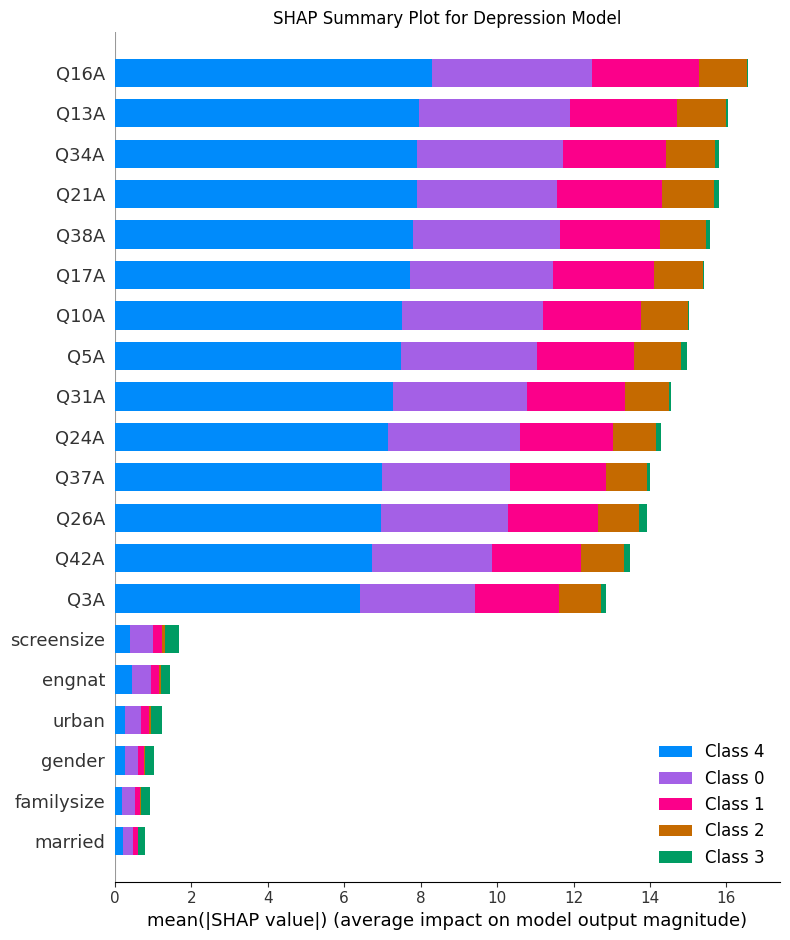

SHAP analysis added for Depression model.


In [77]:
explainer = shap.Explainer(final_dep_model, X_dep_train_scaled)

sample_indices = range(min(100, X_dep_test_scaled.shape[0]))
X_test_sample = X_dep_test_scaled[sample_indices]
shap_values = explainer(X_test_sample)

print("Generating SHAP summary plot for Depression model...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, feature_names=X_dep_test.columns.tolist(), show=False)
plt.title('SHAP Summary Plot for Depression Model')
plt.tight_layout()
plt.show()

print("SHAP analysis added for Depression model.")

### SHAP for Anxiety Model

Generating SHAP summary plot for Anxiety model...


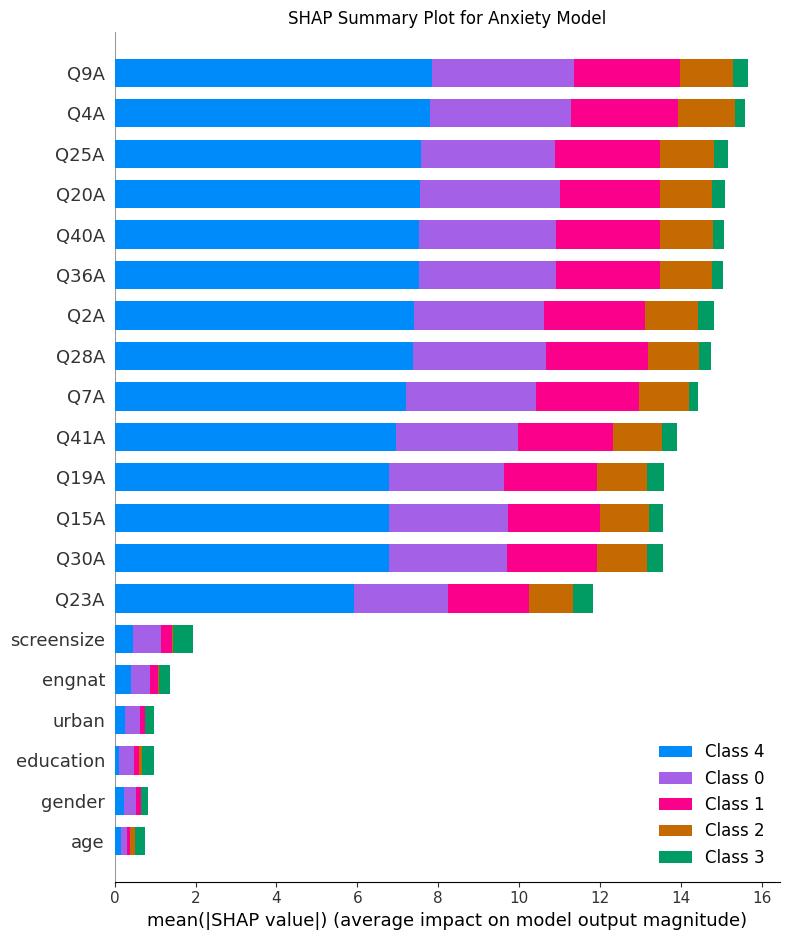

SHAP analysis added for Anxiety model.


In [78]:
explainer_anx = shap.Explainer(final_anx_model, X_anx_train_scaled)

sample_indices_anx = range(min(100, X_anx_test_scaled.shape[0]))
X_test_sample_anx = X_anx_test_scaled[sample_indices_anx]
shap_values_anx = explainer_anx(X_test_sample_anx)

print("Generating SHAP summary plot for Anxiety model...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_anx, X_test_sample_anx, feature_names=X_anx_test.columns.tolist(), show=False)
plt.title('SHAP Summary Plot for Anxiety Model')
plt.tight_layout()
plt.show()

print("SHAP analysis added for Anxiety model.")

### SHAP for Stress Model

Generating SHAP summary plot for Stress model...


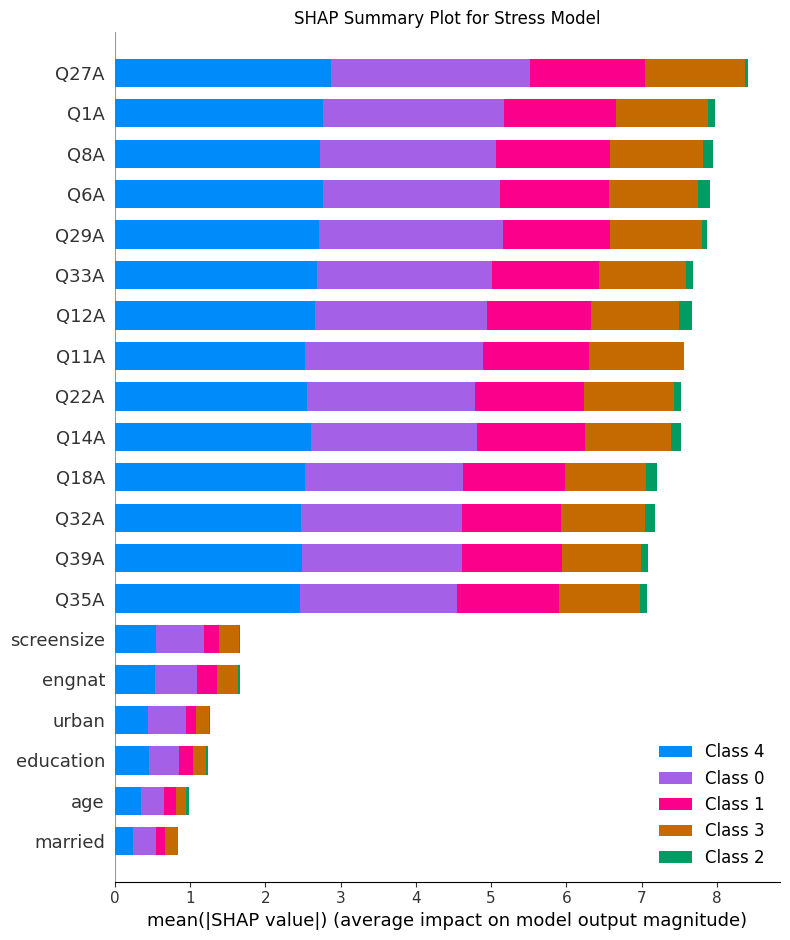

SHAP analysis added for Stress model.


In [79]:
explainer_str = shap.Explainer(final_str_model, X_str_train_scaled)

sample_indices_str = range(min(100, X_str_test_scaled.shape[0]))
X_test_sample_str = X_str_test_scaled[sample_indices_str]
shap_values_str = explainer_str(X_test_sample_str)

print("Generating SHAP summary plot for Stress model...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_str, X_test_sample_str, feature_names=X_str_test.columns.tolist(), show=False)
plt.title('SHAP Summary Plot for Stress Model')
plt.tight_layout()
plt.show()

print("SHAP analysis added for Stress model.")

#### SHAP Analysis Summary: Understanding What Drives Our Predictions

#### 1. Depression Model Insights

Looking at the Depression model's SHAP plot, we can see which questions and personal details really stand out:

*   **Key Symptoms**: Questions like **Q21A** (difficulty rousing yourself), **Q38A** (not able to experience positive feelings), and **Q10A** (feeling no longer worthwhile) tend to have the biggest impact. When someone strongly agrees with these statements, it significantly increases the model's prediction of higher depression severity.
*   **Demographic Influence**: While symptom questions are dominant, demographic factors like **Age** also play a role. For instance, younger individuals might show a slightly different pattern in how their answers contribute to their depression scores, or certain age groups might be more likely to report certain symptoms.

In essence, for depression, our model is heavily listening to direct reports of anhedonia (inability to feel pleasure) and general lack of motivation or self-worth.

#### 2. Anxiety Model Insights

For Anxiety, the model highlights a different set of influential factors:

*   **Core Anxieties**: Symptoms related to panic and worry are prominent. **Q2A** (aware of dryness of my mouth), **Q4A** (experiencing breathing difficulty), and **Q7A** (trembling) are major drivers. High scores on these indicate a strong likelihood of higher anxiety severity.
*   **Physical Manifestations**: The model emphasizes the physical sensations often associated with anxiety, suggesting that these objective (though self-reported) indicators are very telling.

Here, the model is really picking up on the physical and acute emotional distress that comes with anxiety, like feeling keyed up or having physical symptoms of nervousness.

#### 3. Stress Model Insights

Finally, for the Stress model, we observe unique patterns:

*   **Emotional Resilience**: Questions such as **Q1A** (felt I was rather agitated), **Q6A** (tended to over-react to situations), and **Q8A** (found it difficult to relax) are highly impactful. Strong agreement with these items pushes the prediction towards greater stress severity.
*   **Coping Mechanisms & Control**: The model seems sensitive to how individuals perceive their ability to cope and control their emotions and reactions in challenging situations.

For stress, our model seems to be keenly observing how people respond to daily pressures and their capacity to maintain calmness and control.

---

**Overall Takeaway**:

This SHAP analysis helps us confirm that the models are learning meaningful relationships between the reported symptoms and the severity of each mental health condition. It's reassuring to see that the most influential factors align well with clinical understanding of these disorders. It also shows us how, even with generalized models, specific symptoms resonate differently across depression, anxiety, and stress predictions.

### Fairness Check for Demograpic coulmn

In [80]:
def fairness_summary_dataframe(model, X_test_scaled, y_test, 
                                X_test_original, demographics):
    y_pred = model.predict(X_test_scaled)
    results = []

    for demo in demographics:
        mf_acc = MetricFrame(
            metrics=accuracy_score,
            y_true=y_test,
            y_pred=y_pred,
            sensitive_features=X_test_original[demo])
        
        mf_f1 = MetricFrame(
            metrics=lambda yt, yp: f1_score(yt, yp, average="macro"),
            y_true=y_test,
            y_pred=y_pred,
            sensitive_features=X_test_original[demo])
        
        acc_by_group = mf_acc.by_group
        f1_by_group = mf_f1.by_group

        acc_gap = acc_by_group.max() - acc_by_group.min()
        f1_gap = f1_by_group.max() - f1_by_group.min()
        status = "Bias Risk" if (acc_gap > 0.07 or f1_gap > 0.07) else "Fair"
        
        results.append({
            "Feature": demo,
            "Max Accuracy": round(acc_by_group.max(), 3),
            "Min Accuracy": round(acc_by_group.min(), 3),
            "Accuracy Gap": round(acc_gap, 3),
            "Max F1": round(f1_by_group.max(), 3),
            "Min F1": round(f1_by_group.min(), 3),
            "F1 Gap": round(f1_gap, 3),
            "Fairness Status": status
        })
    fairness_df = pd.DataFrame(results)
    return fairness_df

In [81]:
# Depression
dep_fairness_df = fairness_summary_dataframe(
    final_dep_model,
    X_dep_test_scaled,
    y_dep_test,
    X_dep_test,
    demographics)
dep_fairness_df


,Feature,Max Accuracy,Min Accuracy,Accuracy Gap,Max F1,Min F1,F1 Gap,Fairness Status
0,education,0.893,0.837,0.056,0.866,0.801,0.066,Fair
1,urban,0.903,0.860,0.043,0.864,0.790,0.074,Bias Risk
2,gender,0.953,0.818,0.135,0.894,0.803,0.091,Bias Risk
3,engnat,0.890,0.684,0.206,0.853,0.698,0.155,Bias Risk
4,age,1.000,0.333,0.667,1.000,0.200,0.800,Bias Risk
5,screensize,0.906,0.873,0.033,0.871,0.826,0.044,Fair
6,religion,0.955,0.829,0.125,0.920,0.759,0.161,Bias Risk
7,orientation,0.921,0.865,0.057,0.881,0.829,0.052,Fair
8,race,1.000,0.855,0.145,1.000,0.803,0.197,Bias Risk
9,married,0.954,0.731,0.223,0.935,0.607,0.329,Bias Risk


* The model shows significant fairness gaps across age, gender, marital status, and family size, indicating demographic imbalance and potential bias that must be addressed before deployment.

In [82]:
# Anxiety
anx_fairness_df = fairness_summary_dataframe(
    final_anx_model,
    X_anx_test_scaled,
    y_anx_test,
    X_anx_test,
    demographics)
anx_fairness_df

,Feature,Max Accuracy,Min Accuracy,Accuracy Gap,Max F1,Min F1,F1 Gap,Fairness Status
0,education,0.859,0.744,0.116,0.805,0.600,0.205,Bias Risk
1,urban,0.847,0.727,0.120,0.762,0.626,0.136,Bias Risk
2,gender,0.943,0.727,0.216,0.849,0.567,0.283,Bias Risk
3,engnat,0.839,0.700,0.139,0.762,0.647,0.115,Bias Risk
4,age,1.000,0.000,1.000,1.000,0.000,1.000,Bias Risk
5,screensize,0.863,0.807,0.056,0.798,0.708,0.090,Bias Risk
6,religion,0.902,0.750,0.152,0.785,0.585,0.200,Bias Risk
7,orientation,0.857,0.808,0.049,0.762,0.716,0.046,Fair
8,race,0.885,0.750,0.135,0.746,0.500,0.246,Bias Risk
9,married,0.877,0.774,0.103,0.811,0.615,0.196,Bias Risk


In [83]:
# Stress
str_fairness_df = fairness_summary_dataframe(
    final_str_model,
    X_str_test_scaled,
    y_str_test,
    X_str_test,
    demographics)
str_fairness_df

,Feature,Max Accuracy,Min Accuracy,Accuracy Gap,Max F1,Min F1,F1 Gap,Fairness Status
0,education,0.911,0.781,0.131,0.905,0.772,0.133,Bias Risk
1,urban,0.897,0.835,0.063,0.887,0.820,0.066,Fair
2,gender,0.927,0.800,0.127,0.873,0.620,0.253,Bias Risk
3,engnat,0.882,0.824,0.059,0.874,0.785,0.089,Bias Risk
4,age,1.000,0.500,0.500,1.000,0.333,0.667,Bias Risk
5,screensize,0.918,0.855,0.063,0.910,0.844,0.066,Fair
6,religion,0.900,0.786,0.114,0.889,0.755,0.134,Bias Risk
7,orientation,0.908,0.854,0.054,0.893,0.834,0.059,Fair
8,race,1.000,0.865,0.135,1.000,0.853,0.147,Bias Risk
9,married,0.931,0.745,0.186,0.915,0.681,0.235,Bias Risk


### Save All 3 Final Models

In [84]:
Final_DASS_models = {
    "depression_model": final_dep_model,
    "anxiety_model": final_anx_model,
    "stress_model": final_str_model,
    "dep_scaler": scaler_dep,
    "anx_scaler": scaler_anx,
    "str_scaler": scaler_str,}

joblib.dump(Final_DASS_models, "final_dass_system.pkl")

['final_dass_system.pkl']

In [85]:
# Load models
dass_system = joblib.load("final_dass_system.pkl")

dep_model = dass_system["depression_model"]
anx_model = dass_system["anxiety_model"] 

# Predict on first 5 test samples
sample = X_anx_test.iloc[:5]
preds  = anx_model.predict(sample)
labels = [SEVERITY_LABELS[p] for p in preds]

print('Sample Depression predictions:')
for i, (pred, label) in enumerate(zip(preds, labels)):
    print(f'{pred} - {label}')

print('\nModels working correctly.')

Sample Depression predictions:
4 - Extremely Severe
3 - Severe
3 - Severe
4 - Extremely Severe
3 - Severe

Models working correctly.


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


### Reference Statistics

In [86]:
# Generate Reference Stats for Drift Monitoring
import joblib

# The drift monitor will compare the distribution of the incoming scaled features
# against the flattened distribution of the training scaled features.
reference_stats = {
    "dep_train_scaled_flattened": X_dep_train_scaled.flatten(),
    "anx_train_scaled_flattened": X_anx_train_scaled.flatten(),
    "str_train_scaled_flattened": X_str_train_scaled.flatten()
}

joblib.dump(reference_stats, "reference_stats.pkl")
print("Saved reference_stats.pkl for Drift Monitoring.")

Saved reference_stats.pkl for Drift Monitoring.
